rela<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [3]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-08-29 11:54:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  6.01MB/s    in 27s     
2026-08-29 11:55:01 (5.64 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [43]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [44]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [45]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [46]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [48]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [49]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [50]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [51]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [52]:
# First let's convert the data from main table into a dataframe
QUERY = "SELECT * from main"
df = pd.read_sql_query(QUERY, conn)

# Checking the CompTotal column
df["CompTotal"].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

In [53]:
# Checking the highest Total compensations
top_comp = (
    df[["ResponseId", "CompTotal"]]
    .sort_values(by="CompTotal", ascending=False)
    .head(10)
)

top_comp.style.format({
    "CompTotal": "${:,.0f}"
})

,ResponseId,CompTotal
14354,14355,"$1,000,000,000,000,000,162,545,277,246,339,097,227,904,071,986,031,452,381,501,504,981,983,615,182,576,228,378,136,120,296,965,701,983,510,464,738,707,067,395,631,197,433,897,752,887,331,883,780,669,440"
34278,34279,"$99,999,999,999,999,999,209,038,626,283,633,850,822,756,121,694,230,455,365,568,299,008"
17374,17375,"$99,999,999,999,999,999,322,094,867,436,162,797,646,170,844,194,406,400"
8814,8815,"$100,000,000,000,000,008,821,361,405,306,422,640,701,865,984"
20037,20038,"$8,000,000,000,000,000,106,300,440,576"
24677,24678,"$100,000,000,000,000,000,000"
27268,27269,"$1,111,111,111,111,111"
52485,52486,"$304,030,202,020,221"
46992,46993,"$75,874,587,587,576"
59887,59888,"$7,777,777,777,777"


In [54]:
# There are high extremelly outliers what will skew your histogram, let's check the 99th percentile
df["CompTotal"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
90%       1.200000e+06
95%       3.600000e+06
99%       1.177281e+08
99.5%     4.000000e+08
99.9%     9.387503e+09
max      1.000000e+150
Name: CompTotal, dtype: float64

In [55]:
# Checking the number of missing values
print(f"Missing values: {df['CompTotal'].isna().sum():,}")

# Creating a clean series without missing values
comp_total = df["CompTotal"].dropna()

Missing values: 31,697

In [56]:
# Let's create a new column without this top invalid values
df["CompTotalClean"] = df["CompTotal"].where(
    df["CompTotal"].between(0, 40_000_000)
)

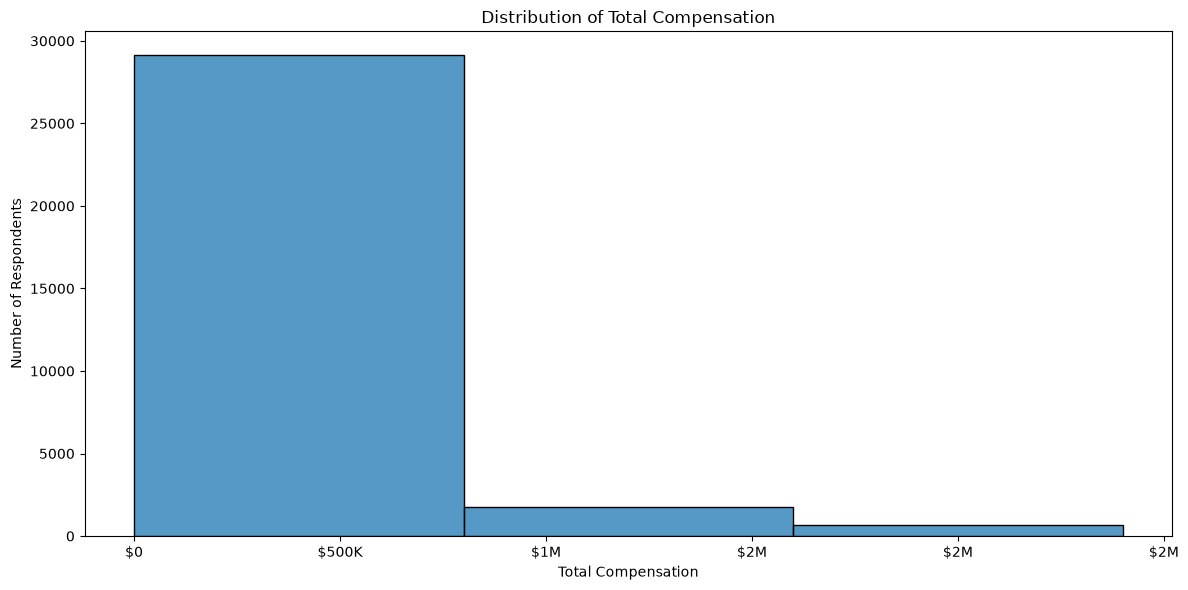

In [57]:
# Plotting histogram
from matplotlib.ticker import FuncFormatter

# Remove missing values
comp_total = df["CompTotalClean"].dropna()

# Find the 99th percentile
upper_limit = comp_total.quantile(0.95)

# Function to format the x labels like 30k 100k 500k 1M 15M values
def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

# Data used only for visualization
comp_total_zoom = comp_total[
    comp_total <= upper_limit
]

plt.figure(figsize=(12, 6))

sns.histplot(
    x=comp_total_zoom,
    bins=3,
    stat="count"
)

plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


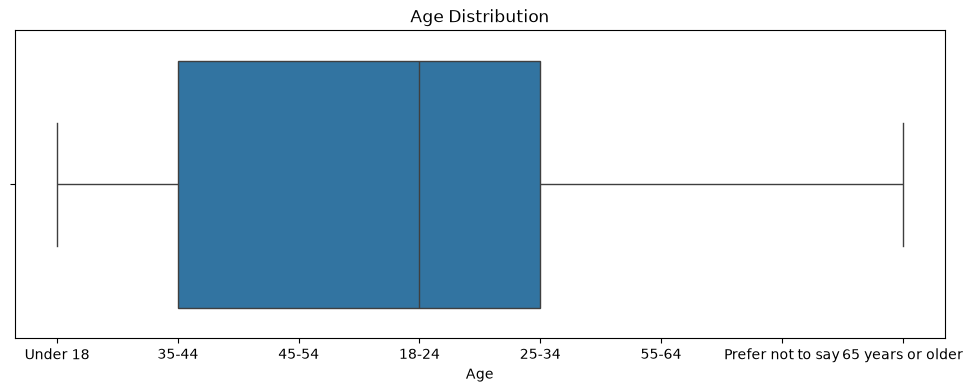

In [58]:
# Let's Check the Age column
df["Age"]

# Let's remove the text "years old" as it's already implied for the column name
df["Age"] = df["Age"].str.replace(" years old", "", regex=False)
df["Age"]

# Creating a box plot 
plt.figure(figsize=(12, 4))

sns.boxplot(x=df["Age"].dropna())

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


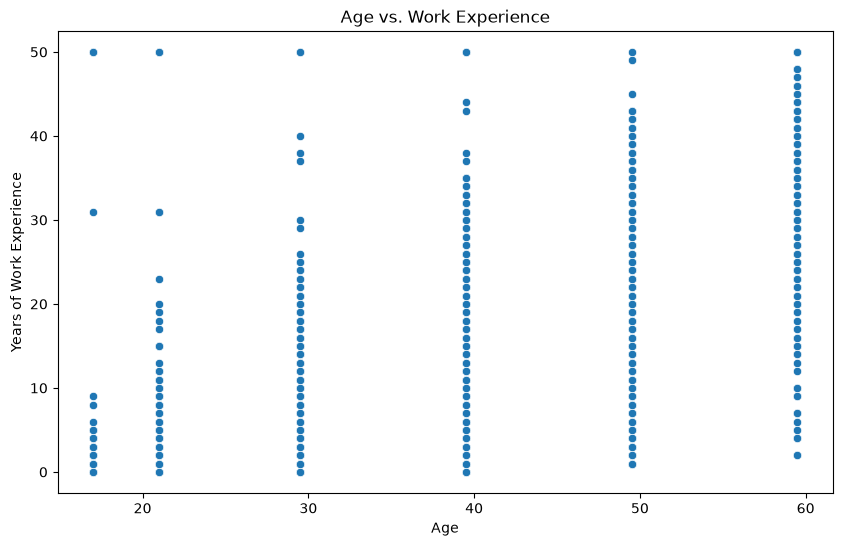

In [59]:
# For Scatter plots Age must be a numerical value and so for it's a age range like 18-24, 25-34...
# Let's create a mapping to update the range to midpoints
age_midpoints = {
    "Under 18": 17,
    "18-24": 21,
    "25-34": 29.5,
    "35-44": 39.5,
    "45-54": 49.5,
    "55-64": 59.5,
    "65 or older": 65
}

# Let's create a new column updated based on midpoints
df["AgeNumeric"] = df["Age"].map(age_midpoints)

# Now let's verify the relationship between them
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="AgeNumeric",
    y="WorkExp"
)

plt.title("Age vs. Work Experience")
plt.xlabel("Age")
plt.ylabel("Years of Work Experience")

plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [60]:
# First let's inpect the columns TimeSearching and Frustration
df["TimeSearching"].unique()

# Let's convert TimeSeacrhing into numerical values
time_searching_map = {
    "Less than 15 minutes a day": 1,
    "15-30 minutes a day": 2,
    "30-60 minutes a day": 3,
    "60-120 minutes a day": 4,
    "Over 120 minutes a day": 5
}

df["TimeSearchingNumeric"] = df["TimeSearching"].map(time_searching_map)

In [61]:
# Let's check Frustration
df["Frustration"].unique()

<ArrowStringArray>
[                                                                                                                                                                                                                                                             nan,
                                                                                                                                                             'Amount of technical debt;Number of software tools in use;Tracking my work;Showing my contributions',
                                                                                                                                                                                               'Amount of technical debt;Complexity of tech stack for deployment',
                                                                                                                'Amount of technical debt;Complexity of tech stack for deployment;Complexity of tech stack f

In [62]:
# Frustration isn't an ordinal scale. It is a multiple-selection categorical column
# Let's create a FrustationCount column base on the number of frustations separated by ";"
df["FrustrationCount"] = (
    df["Frustration"]
    .fillna("")
    .apply(lambda x: 0 if x == "" or x == "None of these"
           else len(x.split(";")))
)

# Checking the op 10 records
df[df["FrustrationCount"]>0].sort_values(by="FrustrationCount", ascending=False)[["Frustration", "FrustrationCount"]]

,Frustration,FrustrationCount
30315,Amount of technical debt;Number of software to...,11
58309,Amount of technical debt;Number of software to...,11
36517,Amount of technical debt;Number of software to...,11
25200,Amount of technical debt;Number of software to...,11
63200,Amount of technical debt;Number of software to...,11
...,...,...
65065,Amount of technical debt,1
65151,Amount of technical debt,1
48901,Amount of technical debt,1
48927,Showing my contributions,1


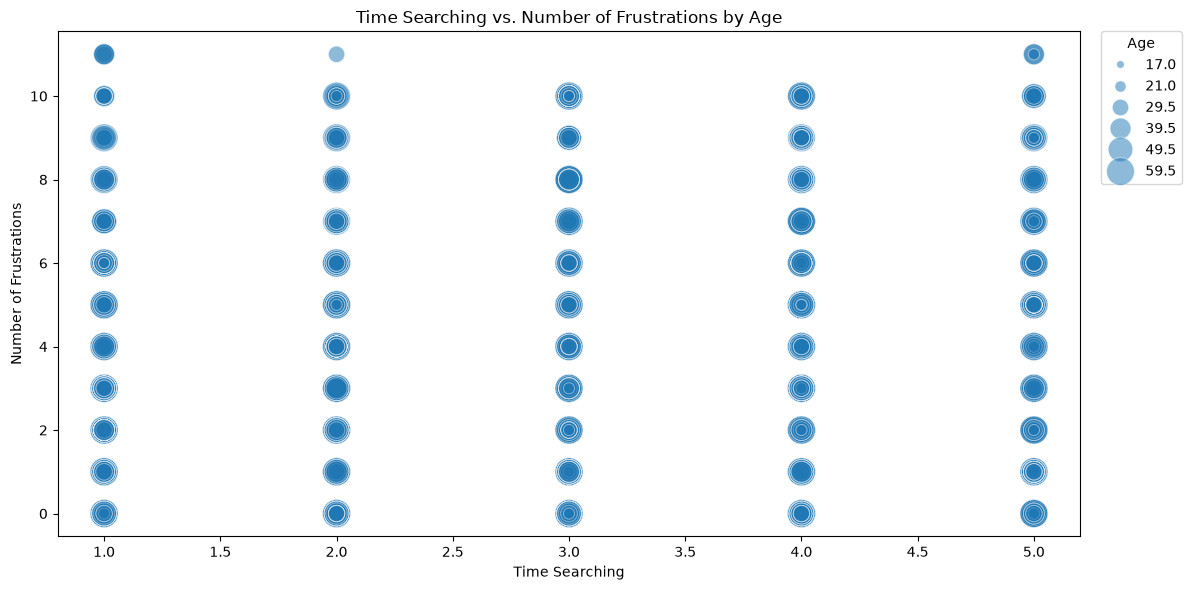

In [63]:
# Now let's create a buble chart based on TimeSearchingNumeric and FrustrationCount
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="TimeSearchingNumeric",
    y="FrustrationCount",
    size="AgeNumeric",
    sizes=(30, 400),
    alpha=0.5
)

plt.title("Time Searching vs. Number of Frustrations by Age")
plt.xlabel("Time Searching")
plt.ylabel("Number of Frustrations")

# Move legend outside the plot
plt.legend(
    title="Age",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [64]:
# Let's check the DatabaseWantToWorkWith column
df["DatabaseWantToWorkWith"].value_counts().head(10)

DatabaseWantToWorkWith
PostgreSQL                 3738
PostgreSQL;SQLite          1533
SQLite                     1476
Microsoft SQL Server       1431
MySQL                      1139
MongoDB                     917
PostgreSQL;Redis            855
MongoDB;PostgreSQL          600
MySQL;PostgreSQL            504
PostgreSQL;Redis;SQLite     411
Name: count, dtype: int64

In [65]:
# Some records contains two or more databases separated by ";". Let's count individually
database_counts = (
    df["DatabaseWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .value_counts()
)

database_counts.head(10)

DatabaseWantToWorkWith
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Dynamodb                 3503
Supabase                 2930
Name: count, dtype: int64

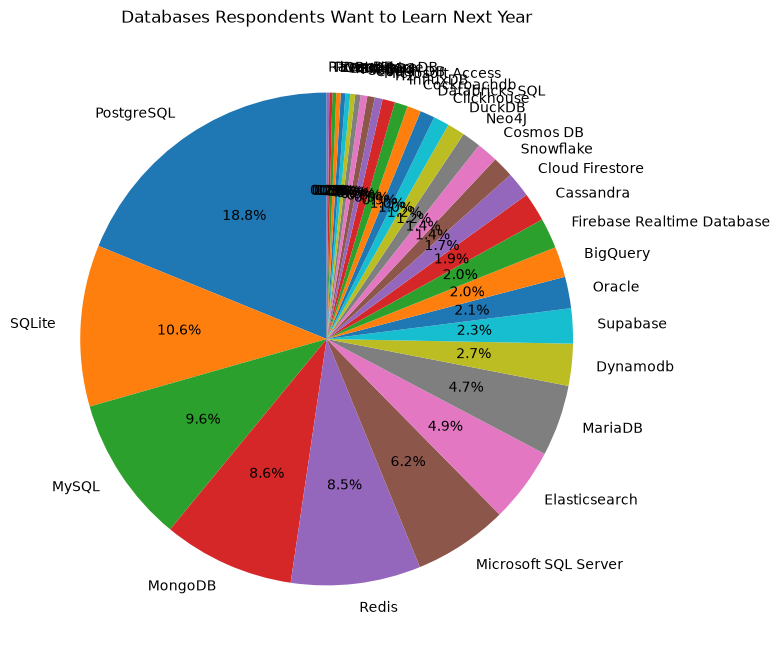

In [66]:
# Let's plot the pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    database_counts,
    labels=database_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Databases Respondents Want to Learn Next Year")

plt.show()

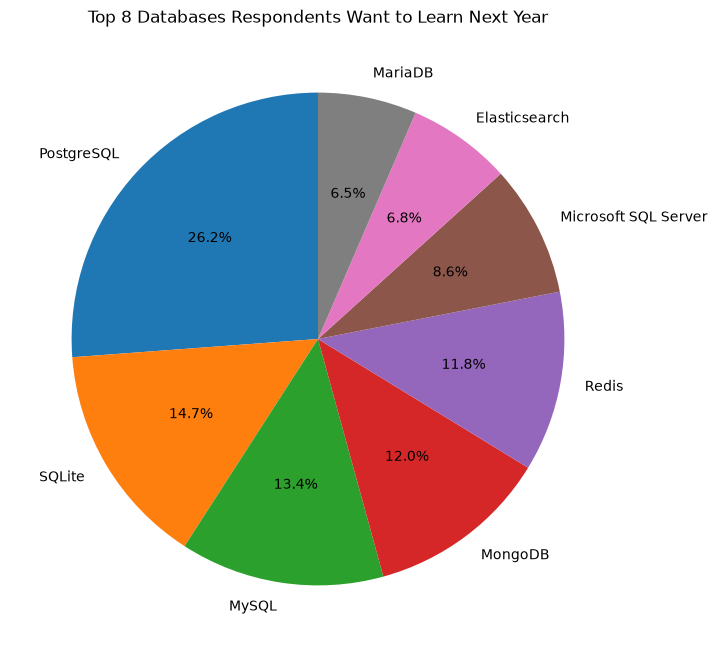

In [67]:
# As there are many different databases the best aproach for a clean pie chart it's create it based on the top 5 or 10 most common databases the respondents asnwered they want to work with
# Let's get the top 8
top_8_databases = database_counts.head(8)

# Then let's render a new PieChart based on the top 8
plt.figure(figsize=(8, 8))

plt.pie(
    top_8_databases,
    labels=top_8_databases.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 8 Databases Respondents Want to Learn Next Year")

plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [68]:
# TimeSearchingNumeric is already categorized in muerical values Let's check TimeAnswering
df["TimeAnswering"].unique()

# Let's map TimeAnswering in numerical values
time_answering_map = {
    "Less than 15 minutes a day": 1,
    "15-30 minutes a day": 2,
    "30-60 minutes a day": 3,
    "60-120 minutes a day": 4,
    "Over 120 minutes a day": 5
}

df["TimeAnsweringNumeric"] = df["TimeAnswering"].map(time_answering_map)

In [69]:
# For this assignment there's a problem
# The Age column categories include 25-34 and 35-44, but not individual ages
# Therefore, you cannot accurately filter respondents aged 30–35 from this column

# Let's create based on the 25-34 age group (closest available catagory)
age_25_34 = df[df["Age"] == "25-34"]

# Now let's check the columns TimeSearching and TimeAnswering 
median_times = age_25_34[
    ["TimeSearchingNumeric", "TimeAnsweringNumeric"]
].median()
median_times

TimeSearchingNumeric    3.0
TimeAnsweringNumeric    2.0
dtype: float64

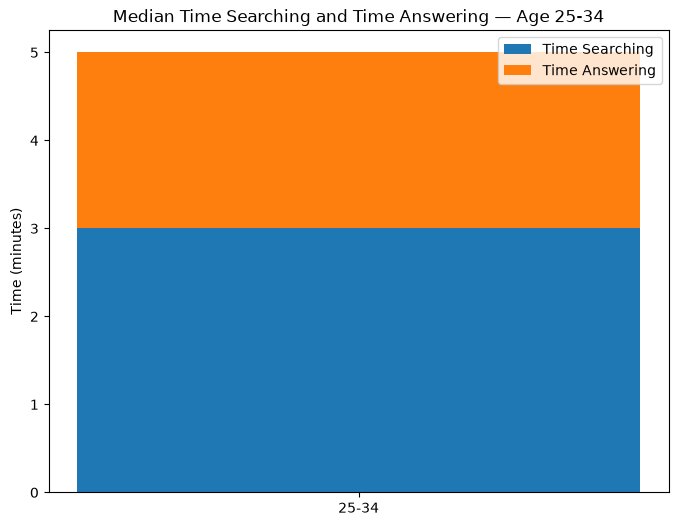

In [70]:
# Creating a Stacked Bar Chart
plt.figure(figsize=(8, 6))

plt.bar(
    ["25-34"],
    [median_times["TimeSearchingNumeric"]],
    label="Time Searching"
)

plt.bar(
    ["25-34"],
    [median_times["TimeAnsweringNumeric"]],
    bottom=[median_times["TimeSearchingNumeric"]],
    label="Time Answering"
)

plt.title("Median Time Searching and Time Answering — Age 25-34")
plt.ylabel("Time (minutes)")
plt.legend()

plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [71]:
# Filtering rows from respondents age 45 to 64
age_45_64 = df[df["Age"].isin(["45-54", "55-64"])]

median_comp = (
    age_45_64
    .groupby("Age")["CompTotalClean"]
    .median()
)

median_comp

Age
45-54    130000.0
55-64    135000.0
Name: CompTotalClean, dtype: float64

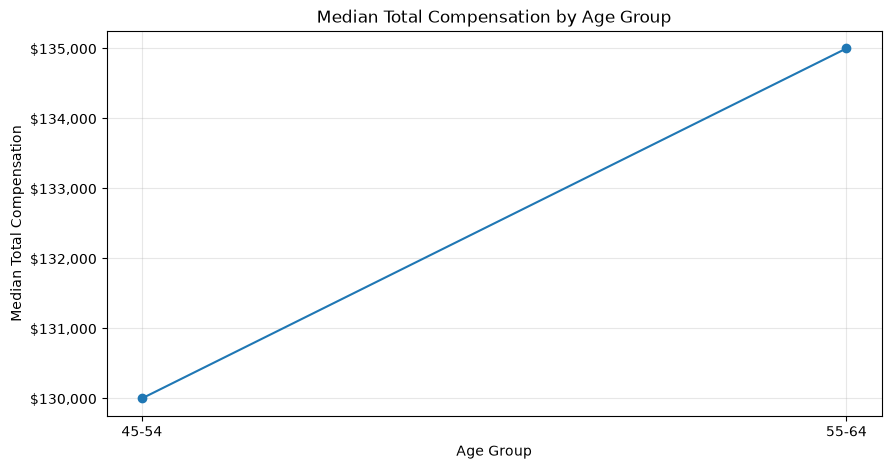

In [72]:
# Creating a Line chart
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))

plt.plot(
    median_comp.index,
    median_comp.values,
    marker="o"
)

plt.title("Median Total Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Total Compensation")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(True, alpha=0.3)

plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [73]:
# Count each mainbranch category
main_branch_counts = df["MainBranch"].value_counts()
main_branch_counts

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64

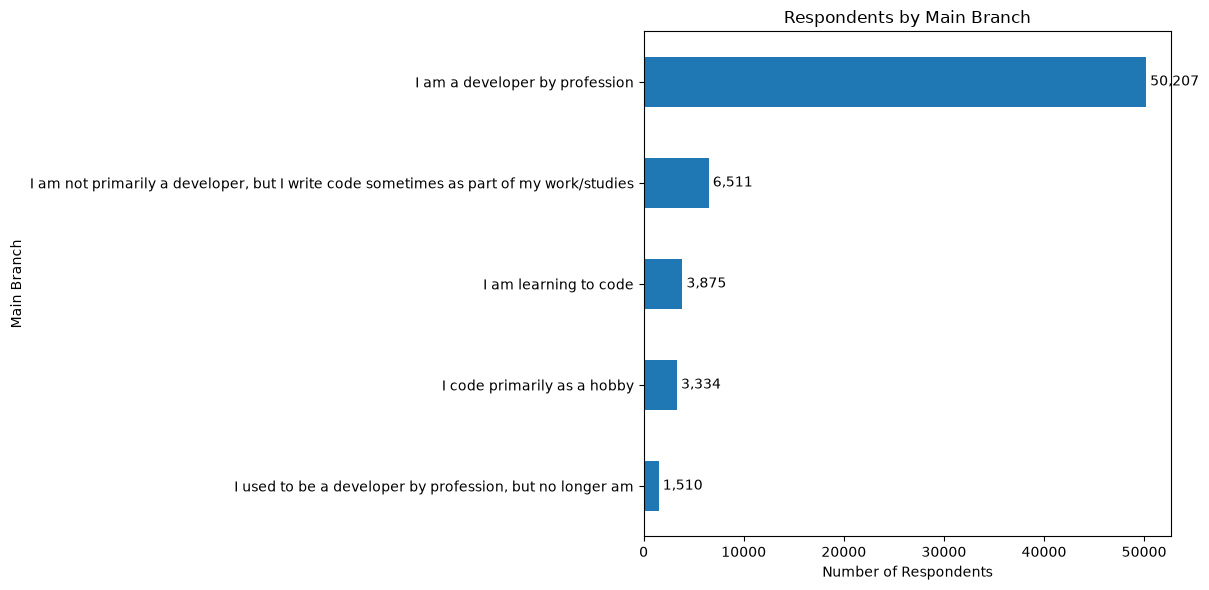

In [36]:
# Creating bar chart by mainbranch category
import matplotlib.pyplot as plt

main_branch_counts = df["MainBranch"].value_counts()

plt.figure(figsize=(12, 6))

ax = main_branch_counts.sort_values().plot(
    kind="barh"
)

plt.title("Respondents by Main Branch")
plt.xlabel("Number of Respondents")
plt.ylabel("Main Branch")

# Add values to the bars
for i, value in enumerate(main_branch_counts.sort_values()):
    ax.text(
        value,
        i,
        f" {value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [116]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
